In [1]:
import requests
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_dir = Path('dataset')
data_dir.mkdir(exist_ok=True)

files = {
    "gamma.csv": "https://zenodo.org/records/8037239/files/gamma.csv?download=1",
    "neutron.csv": "https://zenodo.org/records/8037239/files/neutron.csv?download=1"
}

for filename, url in files.items():
    filepath = data_dir / filename
    if not filepath.exists():
        print(f"Downloading {filename}...")
        res = requests.get(url)
        res.raise_for_status()  # Check if the request was successful

        with open(filepath, 'wb') as f:
            f.write(res.content)
    else:
        print(f"{filename} already exists. Skipping download.")

In [2]:
neutron = pd.read_csv('dataset/neutron.csv')
gamma = pd.read_csv('dataset/gamma.csv')

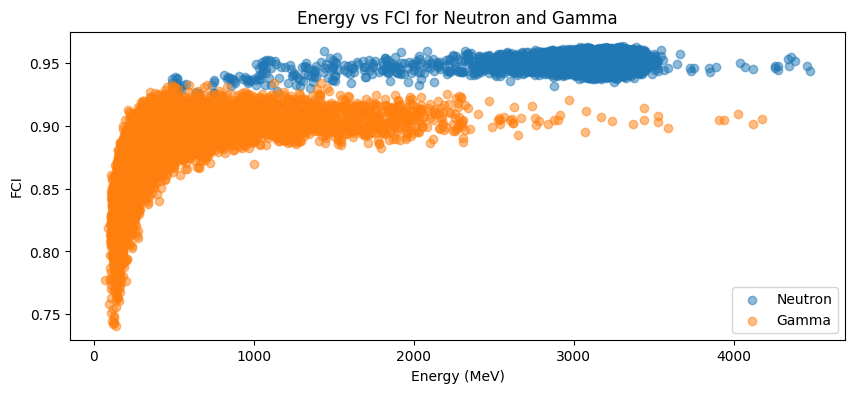

In [4]:
plt.figure(figsize=(10, 4))
plt.scatter(neutron['Energy'], neutron['FCI'], label='Neutron', alpha=0.5)
plt.scatter(gamma['Energy'], gamma['FCI'], label='Gamma', alpha=0.5)
plt.xlabel('Energy (MeV)')
plt.ylabel('FCI')
plt.title('Energy vs FCI for Neutron and Gamma')
plt.legend()
plt.show()

In [3]:
neutron_vect = np.array(neutron.iloc[:, :-4])
gamma_vect = np.array(gamma.iloc[:, :-4])

In [ ]:
print("Neutron data shape: ", neutron_vect.shape)
print("Gamma data shape: ", gamma_vect.shape)

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
for i in range(neutron_vect.shape[0]):
    plt.plot(neutron_vect[i, :], label=f'Neutron {i}', color='tab:blue', alpha=0.5)
plt.ylim(0, 550)
plt.subplot(2, 1, 2)
for i in range(gamma_vect.shape[0]):
    plt.plot(gamma_vect[i, :], label=f'Gamma {i}', color='tab:green', alpha=0.5)
plt.ylim(0, 550)

Neutron data shape:  (27696, 3000)
Gamma data shape:  (10913, 3000)


KeyboardInterrupt: 

In [4]:
cont = 0
for i in range(neutron_vect.shape[0]):
    if (np.mean(neutron_vect[i, 10:100]) < 450):
        neutron_vect[i, :] += 100
        cont += 1

print(f"Number of neutron samples adjusted: {cont}")

cont = 0
for i in range(gamma_vect.shape[0]):
    if (np.mean(gamma_vect[i, 10:100]) < 450):
        gamma_vect[i, :] += 100
        cont += 1   
print(f"Number of gamma samples adjusted: {cont}")  


Number of neutron samples adjusted: 21639
Number of gamma samples adjusted: 8338


Neutron data shape:  (27696, 3000)
Gamma data shape:  (10913, 3000)


(0.0, 550.0)

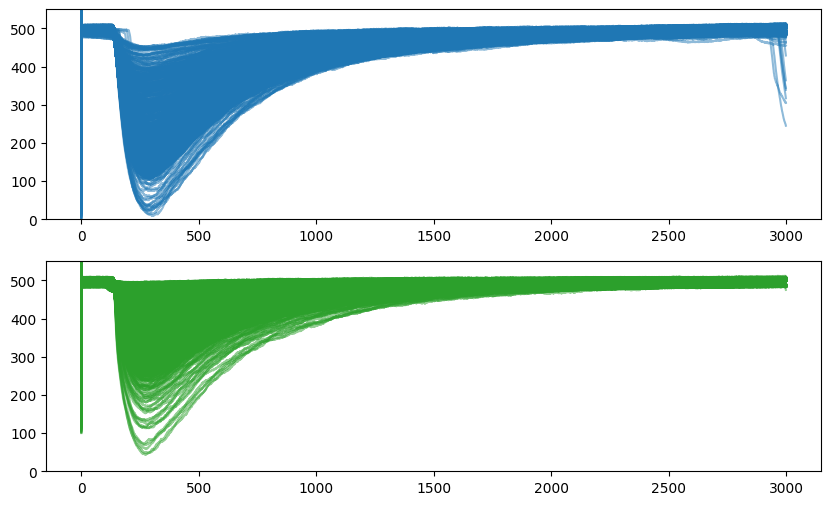

In [19]:
print("Neutron data shape: ", neutron_vect.shape)
print("Gamma data shape: ", gamma_vect.shape)

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
for i in range(neutron_vect.shape[0]):
    plt.plot(neutron_vect[i, :], label=f'Neutron {i}', color='tab:blue', alpha=0.5)
plt.ylim(0, 550)
plt.subplot(2, 1, 2)
for i in range(gamma_vect.shape[0]):
    plt.plot(gamma_vect[i, :], label=f'Gamma {i}', color='tab:green', alpha=0.5)
plt.ylim(0, 550)

In [5]:
def compute_energy_psd(pulses):

    n_events, n_samples = pulses.shape

    energy = np.zeros(n_events)
    psd = np.zeros(n_events)

    for i in range(n_events):

        pulse = pulses[i]

        baseline = pulse[:5].mean()

        signal = baseline - pulse
        signal[signal < 0] = 0

        total = signal.sum()

        peak = np.argmax(signal)

        # inicio de la cola
        tail_start = peak + 5

        tail = signal[tail_start:].sum()

        energy[i] = total
        psd[i] = tail / total if total > 0 else 0

    return energy, psd

In [6]:
indices = np.linspace(100, 2500 - 1, 161, dtype=int)
newNeutron = neutron_vect[:, indices]
newGamma = gamma_vect[:, indices]

In [7]:
# calcular para ambos datasets
energy_neutron, psd_neutron = compute_energy_psd(newNeutron)
energy_gamma, psd_gamma = compute_energy_psd(newGamma)

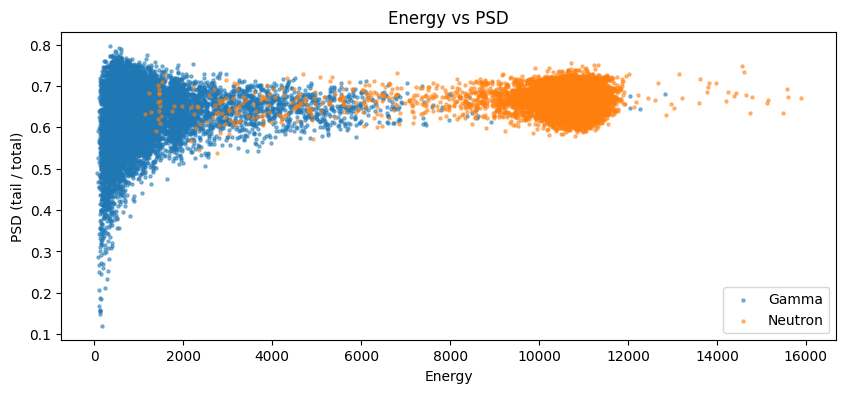

In [8]:
plt.figure(figsize=(10, 4))

plt.scatter(energy_gamma, psd_gamma, s=5, alpha=0.5, label="Gamma")
plt.scatter(energy_neutron, psd_neutron, s=5, alpha=0.5, label="Neutron")

plt.xlabel("Energy")
plt.ylabel("PSD (tail / total)")
plt.title("Energy vs PSD")

plt.legend()
plt.show()

In [9]:
# Convertir a DataFrame
df_neutron = pd.DataFrame(newNeutron)
df_gamma = pd.DataFrame(newGamma)

# Agregar columna de clase
df_neutron["class"] = 1
df_gamma["class"] = 0

n_samples = 1000

# Seleccionar test
test_neutron = df_neutron.sample(n=n_samples, random_state=45)
test_gamma = df_gamma.sample(n=n_samples, random_state=45)

# Crear train eliminando esas filas
train_neutron = df_neutron.drop(test_neutron.index)
train_gamma = df_gamma.drop(test_gamma.index)

# Construir datasets finales
test_df = pd.concat([test_neutron, test_gamma], axis=0)
train_df = pd.concat([train_neutron, train_gamma], axis=0)

# Mezclar filas
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Guardar CSV
test_df.to_csv("dataset/test_dataset.csv", index=False)
train_df.to_csv("dataset/train_dataset.csv", index=False)
train_gamma.to_csv("dataset/train_gamma_dataset.csv", index=False)
train_neutron.to_csv("dataset/train_neutron_dataset.csv", index=False)

Gamma dataset shape:  (9913, 162)
Neutron dataset shape:  (26696, 162)


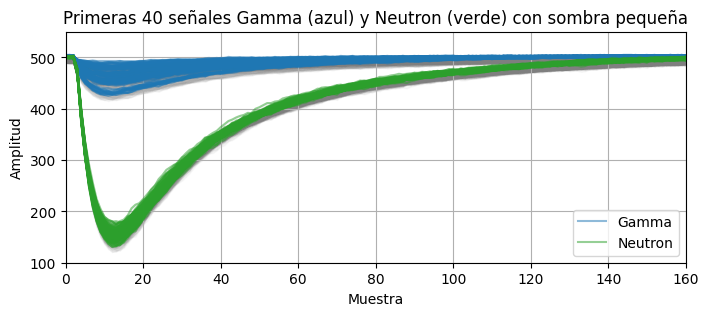

In [10]:
# Explore datasets and plot some signals
print("Gamma dataset shape: ", train_gamma.shape)
print("Neutron dataset shape: ", train_neutron.shape)

plt.figure(figsize=(8, 3))

# Graficar 40 señales gamma en azul con sombra pequeña debajo de la línea
for i in range(100):
    y = train_gamma.iloc[i, :-1]
    x = range(len(y))
    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

# Graficar 40 señales neutron en verde con sombra pequeña debajo de la línea
for i in range(100):
    y = train_neutron.iloc[i, :-1]
    x = range(len(y))
    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

plt.title("Primeras 40 señales Gamma (azul) y Neutron (verde) con sombra pequeña")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.xlim(0, 160)
plt.ylim(100, 550)
plt.legend()
plt.grid()
plt.show()

Gamma dataset shape: (9913, 162)
Neutron dataset shape: (26696, 162)


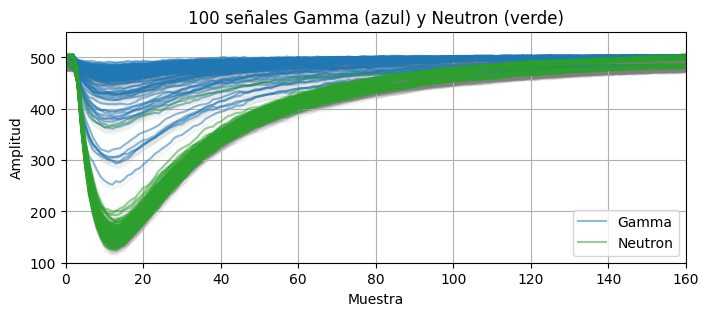

In [11]:
# separar clases
train_gamma_new = train_df[train_df["class"] == 0]
train_neutron_new = train_df[train_df["class"] == 1]

print("Gamma dataset shape:", train_gamma_new.shape)
print("Neutron dataset shape:", train_neutron_new.shape)

plt.figure(figsize=(8,3))

# gamma
for i in range(100):
    y = train_gamma_new.iloc[i, :-1]
    x = range(len(y))

    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)

# neutron
for i in range(100):
    y = train_neutron_new.iloc[i, :-1]
    x = range(len(y))

    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)

plt.title("100 señales Gamma (azul) y Neutron (verde)")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")

plt.xlim(0,160)
plt.ylim(100,550)

plt.legend()
plt.grid()
plt.show()